In [1]:
# import libraries
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

from tqdm import tqdm

In [3]:
# device setup 
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

Using device: cpu


In [ ]:
# define tranforms (w/0 augmentation)
basic_transform = transforms.Compose([

    transforms.ToTensor(),

    transforms.Normalize(
        (0.5, 0.5, 0.5),
        (0.5, 0.5, 0.5))])

In [6]:
# transform with augmentation (4)
aug_transform = transforms.Compose([

    transforms.RandomCrop(32, padding=4),

    transforms.RandomHorizontalFlip(),

    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        (0.5, 0.5, 0.5),
        (0.5, 0.5, 0.5)
    )
])

In [7]:
# load the dataset 

train_dataset_basic = datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=basic_transform
)

train_dataset_aug = datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=aug_transform
)

test_dataset = datasets.CIFAR10(
    root='./data',
    train=False,
    download=True,
    transform=basic_transform
)

In [8]:
# dataloaders 

batch_size = 64

train_loader_basic = DataLoader(
    train_dataset_basic,
    batch_size=batch_size,
    shuffle=True
)

train_loader_aug = DataLoader(
    train_dataset_aug,
    batch_size=batch_size,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

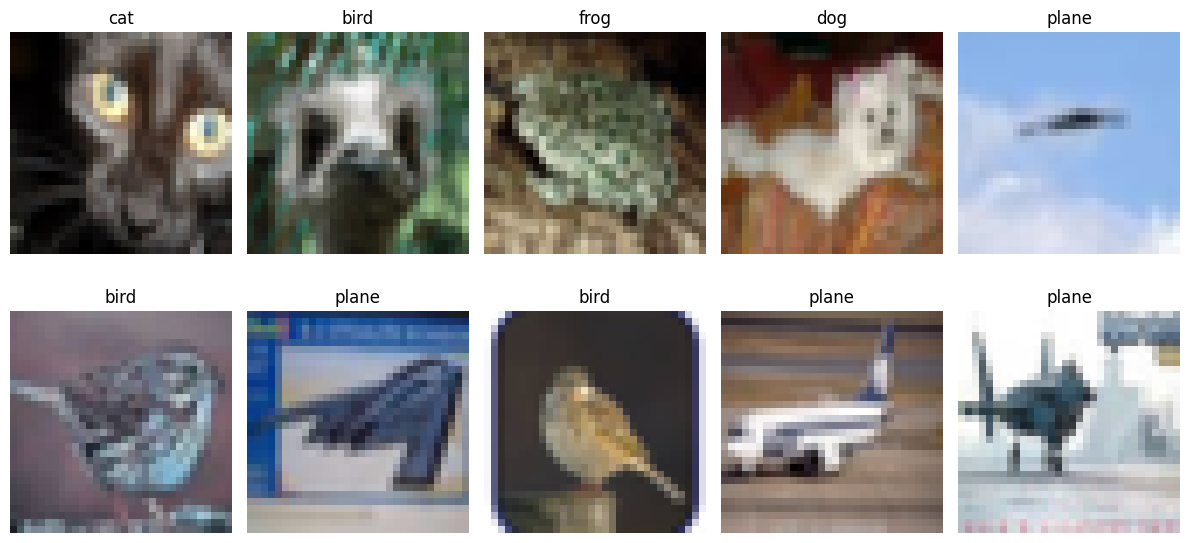

In [9]:
# visualize the dataset 

classes = (
    'plane', 'car', 'bird', 'cat',
    'deer', 'dog', 'frog', 'horse',
    'ship', 'truck'
)

images, labels = next(iter(train_loader_basic))

plt.figure(figsize=(12,6))

for i in range(10):

    plt.subplot(2,5,i+1)

    img = images[i] / 2 + 0.5

    npimg = img.numpy()

    plt.imshow(np.transpose(npimg, (1,2,0)))

    plt.title(classes[labels[i]])

    plt.axis('off')

plt.tight_layout()
plt.show()

In [11]:
# configurable CNN
class SimpleCNN(nn.Module):

    def __init__(self,
                 use_bn=False,
                 use_dropout=False):

        super(SimpleCNN, self).__init__()

        self.use_bn = use_bn
        self.use_dropout = use_dropout

        # Conv Layer 1
        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)

        self.bn1 = nn.BatchNorm2d(32)

        # Conv Layer 2
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)

        self.bn2 = nn.BatchNorm2d(64)

        # Pooling
        self.pool = nn.MaxPool2d(2,2)

        # Dropout
        self.dropout = nn.Dropout(0.3)

        # Fully Connected
        self.fc1 = nn.Linear(64 * 8 * 8, 128)

        self.fc2 = nn.Linear(128, 10)

        self.relu = nn.ReLU()

    def forward(self, x):

        # Conv Block 1
        x = self.conv1(x)

        if self.use_bn:
            x = self.bn1(x)

        x = self.relu(x)

        x = self.pool(x)

        # Conv Block 2
        x = self.conv2(x)

        if self.use_bn:
            x = self.bn2(x)

        x = self.relu(x)

        x = self.pool(x)

        # Flatten
        x = x.view(x.size(0), -1)

        # FC Layer
        x = self.fc1(x)

        x = self.relu(x)

        if self.use_dropout:
            x = self.dropout(x)

        x = self.fc2(x)

        return x

In [12]:
# train function 

def train_model(model,
                train_loader,
                test_loader,
                epochs=10):

    criterion = nn.CrossEntropyLoss()

    optimizer = optim.Adam(
        model.parameters(),
        lr=0.001
    )

    train_losses = []
    val_losses = []

    train_accs = []
    val_accs = []

    for epoch in range(epochs):

        # TRAINING
        model.train()

        running_loss = 0

        correct = 0

        total = 0

        for images, labels in tqdm(train_loader):

            images = images.to(device)

            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)

            loss = criterion(outputs, labels)

            loss.backward()

            optimizer.step()

            running_loss += loss.item()

            _, predicted = torch.max(outputs,1)

            total += labels.size(0)

            correct += (predicted == labels).sum().item()

        train_loss = running_loss / len(train_loader)

        train_acc = 100 * correct / total

        # VALIDATION
        model.eval()

        val_loss = 0

        correct = 0

        total = 0

        with torch.no_grad():

            for images, labels in test_loader:

                images = images.to(device)

                labels = labels.to(device)

                outputs = model(images)

                loss = criterion(outputs, labels)

                val_loss += loss.item()

                _, predicted = torch.max(outputs,1)

                total += labels.size(0)

                correct += (predicted == labels).sum().item()

        val_loss /= len(test_loader)

        val_acc = 100 * correct / total

        train_losses.append(train_loss)

        val_losses.append(val_loss)

        train_accs.append(train_acc)

        val_accs.append(val_acc)

        print(f"\nEpoch {epoch+1}")

        print(f"Train Loss: {train_loss:.4f}")

        print(f"Val Loss: {val_loss:.4f}")

        print(f"Train Acc: {train_acc:.2f}%")

        print(f"Val Acc: {val_acc:.2f}%")

    return {
        'train_losses': train_losses,
        'val_losses': val_losses,
        'train_accs': train_accs,
        'val_accs': val_accs
    }

In [13]:
# CONDITION 1

model1 = SimpleCNN(
    use_bn=False,
    use_dropout=False
).to(device)

results1 = train_model(
    model1,
    train_loader_basic,
    test_loader
)

100%|██████████| 782/782 [00:51<00:00, 15.05it/s]



Epoch 1
Train Loss: 1.3741
Val Loss: 1.0899
Train Acc: 50.60%
Val Acc: 60.93%


100%|██████████| 782/782 [00:46<00:00, 16.79it/s]



Epoch 2
Train Loss: 0.9830
Val Loss: 0.9279
Train Acc: 65.19%
Val Acc: 67.20%


100%|██████████| 782/782 [00:40<00:00, 19.39it/s]


...


Epoch 8
Train Loss: 0.3853
Val Loss: 0.9706
Train Acc: 86.58%
Val Acc: 71.63%


100%|██████████| 782/782 [00:41<00:00, 19.00it/s]



Epoch 9
Train Loss: 0.3158
Val Loss: 1.0473
Train Acc: 88.86%
Val Acc: 70.82%


100%|██████████| 782/782 [00:40<00:00, 19.28it/s]



Epoch 10
Train Loss: 0.2570
Val Loss: 1.1484
Train Acc: 91.17%
Val Acc: 70.45%


In [14]:
# CONDITION 2
model2 = SimpleCNN(
    use_bn=True,
    use_dropout=False
).to(device)

results2 = train_model(
    model2,
    train_loader_basic,
    test_loader
)


100%|██████████| 782/782 [00:45<00:00, 17.38it/s]



Epoch 1
Train Loss: 1.2153
Val Loss: 0.9879
Train Acc: 56.35%
Val Acc: 64.96%


100%|██████████| 782/782 [00:49<00:00, 15.92it/s]



Epoch 2
Train Loss: 0.9102
Val Loss: 0.8739
Train Acc: 67.96%
Val Acc: 69.27%


100%|██████████| 782/782 [01:02<00:00, 12.49it/s]


...


Epoch 8
Train Loss: 0.4708
Val Loss: 0.8076
Train Acc: 83.44%
Val Acc: 73.88%


100%|██████████| 782/782 [00:56<00:00, 13.94it/s]



Epoch 9
Train Loss: 0.4158
Val Loss: 0.8276
Train Acc: 85.41%
Val Acc: 73.96%


100%|██████████| 782/782 [01:01<00:00, 12.76it/s]



Epoch 10
Train Loss: 0.3760
Val Loss: 0.8554
Train Acc: 86.64%
Val Acc: 74.51%


In [15]:
# CONDITION 3
model3 = SimpleCNN(
    use_bn=True,
    use_dropout=True
).to(device)

results3 = train_model(
    model3,
    train_loader_basic,
    test_loader
)

100%|██████████| 782/782 [01:04<00:00, 12.20it/s]



Epoch 1
Train Loss: 1.4450
Val Loss: 1.1029
Train Acc: 47.66%
Val Acc: 60.97%


100%|██████████| 782/782 [01:30<00:00,  8.61it/s]



Epoch 2
Train Loss: 1.1330
Val Loss: 1.0062
Train Acc: 59.87%
Val Acc: 64.31%


100%|██████████| 782/782 [01:21<00:00,  9.63it/s]


...


Epoch 8
Train Loss: 0.7432
Val Loss: 0.8004
Train Acc: 73.49%
Val Acc: 72.86%


100%|██████████| 782/782 [01:00<00:00, 13.00it/s]



Epoch 9
Train Loss: 0.7160
Val Loss: 0.7644
Train Acc: 74.61%
Val Acc: 73.48%


100%|██████████| 782/782 [01:08<00:00, 11.47it/s]



Epoch 10
Train Loss: 0.6769
Val Loss: 0.8364
Train Acc: 75.94%
Val Acc: 71.59%


In [16]:
# CONDITION 4

model4 = SimpleCNN(
    use_bn=True,
    use_dropout=True
).to(device)

results4 = train_model(
    model4,
    train_loader_aug,
    test_loader
)

100%|██████████| 782/782 [01:13<00:00, 10.59it/s]



Epoch 1
Train Loss: 1.6994
Val Loss: 1.2755
Train Acc: 37.24%
Val Acc: 53.40%


100%|██████████| 782/782 [01:12<00:00, 10.80it/s]



Epoch 2
Train Loss: 1.4426
Val Loss: 1.1235
Train Acc: 47.16%
Val Acc: 61.46%


100%|██████████| 782/782 [01:17<00:00, 10.08it/s]


...


Epoch 8
Train Loss: 1.1528
Val Loss: 0.9231
Train Acc: 58.99%
Val Acc: 67.94%


100%|██████████| 782/782 [01:30<00:00,  8.62it/s]



Epoch 9
Train Loss: 1.1261
Val Loss: 0.8817
Train Acc: 60.18%
Val Acc: 69.43%


100%|██████████| 782/782 [01:19<00:00,  9.80it/s]



Epoch 10
Train Loss: 1.1117
Val Loss: 0.8676
Train Acc: 60.24%
Val Acc: 69.86%


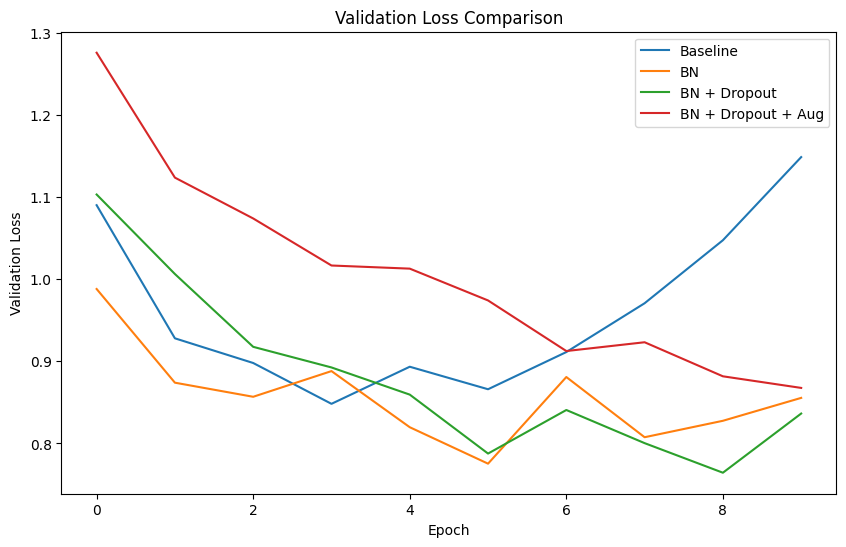

In [17]:
# PLOT CUVES    

plt.figure(figsize=(10,6))

plt.plot(results1['val_losses'],
         label='Baseline')

plt.plot(results2['val_losses'],
         label='BN')

plt.plot(results3['val_losses'],
         label='BN + Dropout')

plt.plot(results4['val_losses'],
         label='BN + Dropout + Aug')

plt.xlabel("Epoch")

plt.ylabel("Validation Loss")

plt.title("Validation Loss Comparison")

plt.legend()

plt.show()

In [18]:
# Result table 

results_table = pd.DataFrame({

    'Condition': [
        'Baseline',
        'BatchNorm',
        'BN + Dropout',
        'BN + Dropout + Aug'
    ],

    'Final Train Acc': [

        results1['train_accs'][-1],
        results2['train_accs'][-1],
        results3['train_accs'][-1],
        results4['train_accs'][-1]
    ],

    'Final Val Acc': [

        results1['val_accs'][-1],
        results2['val_accs'][-1],
        results3['val_accs'][-1],
        results4['val_accs'][-1]
    ]
})

results_table['Overfitting Gap'] = (

    results_table['Final Train Acc']
    -
    results_table['Final Val Acc']
)

results_table

,Condition,Final Train Acc,Final Val Acc,Overfitting Gap
0,Baseline,91.168,70.45,20.718
1,BatchNorm,86.642,74.51,12.132
2,BN + Dropout,75.944,71.59,4.354
3,BN + Dropout + Aug,60.236,69.86,-9.624
